In [1]:
import pandas as pd
import ast
import re

In [2]:
df = pd.read_csv(r"C:\Users\kytus\Desktop\ProjecteData\Equip_25\Data\clean_data_24-03-2026.csv",parse_dates=['insert_date','first_review_date','last_review_date'])

In [4]:
df_anterior = pd.read_csv(r"C:\Users\kytus\Desktop\ProjecteData\Equip_25\Data\clean_data_16-03-2026.csv",parse_dates=['insert_date','first_review_date','last_review_date'])

In [5]:
mediageneral=df['price'].mean().round(2)
medinageneral=df['price'].median().round(2)

mediageneral_ant=df_anterior['price'].mean().round(2)
medinageneral_ant=df_anterior['price'].median().round(2)
print(f"La mediana es: {medinageneral}")
print(f"La media es: {mediageneral}")
print(f"La mediana anterior es: {medinageneral_ant}")
print(f"La media es: {mediageneral_ant}")

La mediana es: 750.0
La media es: 1020.66
La mediana anterior es: 750.0
La media es: 1007.01


In [ ]:
# 1. Agrupamos por barrio para ver el rendimiento medio
analisis_barrios = df.groupby('neighbourhood_name').agg({
    'number_of_reviews': 'mean',
    'review_scores_location': 'mean',
    'minimum_nights': 'mean',
    'maximum_nights': 'mean',  
    'apartment_id': 'count'                # Volumen de anuncios
}).rename(columns={'id': 'total_anuncios'})

# 2. Calculamos un "Índice de Potencial"
# El potencial es alto donde la zona es buena pero las noches disponibles "sobran" 
# porque no se están llenando (quizás por mala gestión reflejada en reviews)
analisis_barrios['potencial_opt'] = (analisis_barrios['availability_365'] * (10 - analisis_barrios['review_scores_location']))

# 3. Ordenamos para ver los barrios con más "trabajo por hacer"
top_optimizacion = analisis_barrios.sort_values(by='potencial_opt', ascending=False)

Revisión outliers

In [32]:
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers

# Ejemplo con disponibilidad
outliers_max_noche = detectar_outliers_iqr(df, 'maximum_nights')
outliers_min_noche = detectar_outliers_iqr(df, 'minimum_nights')
outliers_review = detectar_outliers_iqr(df, 'number_of_reviews')
outliers_loc =detectar_outliers_iqr(df, 'review_scores_location')
print(f"Detectados {len(outliers_max_noche)} alojamientos con maxima noche")
print(f"Detectados {len(outliers_min_noche)} alojamientos con menos noches minimas")
print(f"Detectados {len(outliers_review)} alojamientos con numero de reviews anómala")
print(f"Detectados {len(outliers_loc)} alojamientos con puntuacion de localizacion anómala")

Detectados 0 alojamientos con maxima noche
Detectados 622 alojamientos con menos noches minimas
Detectados 1114 alojamientos con numero de reviews anómala
Detectados 116 alojamientos con puntuacion de localizacion anómala


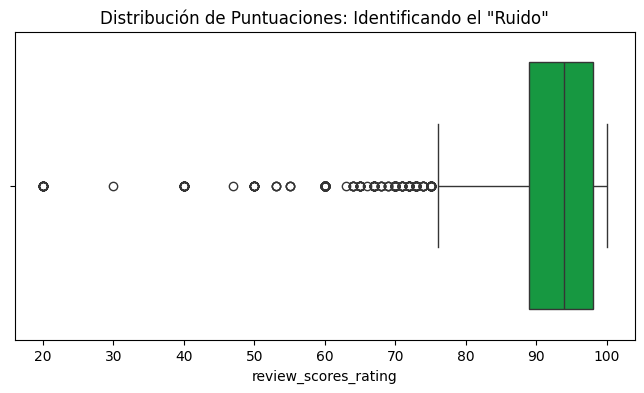

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['review_scores_rating'], color='#02AD3A')
plt.title('Distribución de Puntuaciones: Identificando el "Ruido"')
plt.show()

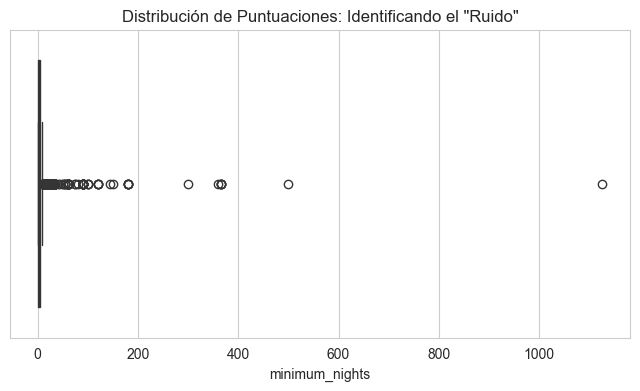

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['minimum_nights'], color='#02AD3A')
plt.title('Distribución de Puntuaciones: Identificando el "Ruido"')
plt.show()

In [39]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Preparación de datos (Filtro n > 50 y Logs)
df_sfa = df[df.groupby('neighbourhood_name')['apartment_id'].transform('count') >= 50].copy()
df_sfa['log_reviews'] = np.log1p(df_sfa['number_of_reviews'])
df_sfa['log_min'] = np.log1p(df_sfa['minimum_nights'])
df_sfa['log_max'] = np.log1p(df_sfa['maximum_nights'])

features = ['log_reviews', 'log_min', 'log_max']
target = 'review_scores_location'

# 2. Análisis por Ciudad
resultados_impacto = []

for ciudad in df_sfa['city'].unique():
    df_c = df_sfa[df_sfa['city'] == ciudad].dropna(subset=features + [target])
    
    if len(df_c) > 100:
        # Escalamos para que los coeficientes sean comparables (Importante!)
        scaler = StandardScaler()
        X = scaler.fit_transform(df_c[features])
        y = df_c[target]
        
        modelo = LinearRegression().fit(X, y)
        
        # Guardamos la importancia de cada variable en esa ciudad
        resultados_impacto.append({
            'Ciudad': ciudad,
            'Impacto_Reviews': modelo.coef_[0],
            'Impacto_Min_Nights': modelo.coef_[1],
            'Impacto_Max_Nights': modelo.coef_[2]
        })

df_impacto = pd.DataFrame(resultados_impacto).set_index('Ciudad')

# 3. Mostrar qué variable "manda" en cada sitio
print("--- Peso de cada variable en la puntuación de zona ---")
print(df_impacto.round(4))

--- Peso de cada variable en la puntuación de zona ---
           Impacto_Reviews  Impacto_Min_Nights  Impacto_Max_Nights
Ciudad                                                            
Malaga              0.7125              0.3152             -0.1847
Barcelona           0.7489             -0.1136             -0.3918
Madrid              0.7524             -0.0396             -0.1122
Girona              1.2317              0.3179             -0.0795
Mallorca            0.6858             -0.0828             -0.2777


In [25]:
df_barrio = df.pivot_table(index='neighbourhood_name', values='apartment_id', aggfunc='count')
df_barrio.sort_values(by='apartment_id',ascending=True)

,apartment_id
neighbourhood_name,
la Trinitat Nova,1
Amer,1
Sales de Llierca,1
Salt,1
Salvador,1
...,...
el Raval,206
Palma de Mallorca,209
Embajadores,278


In [30]:
barrios_pequenos = df_barrio[df_barrio['apartment_id'] < 50].sort_values(by='apartment_id', ascending=True)

# 3. Visualizamos
print(f"Hay {len(barrios_pequenos)} barrios con menos de 50 alojamientos.")
print(barrios_pequenos)

Hay 475 barrios con menos de 50 alojamientos.
                            apartment_id
neighbourhood_name                      
la Vall d'Hebron                       1
Bami                                   1
Vallfogona de Ripoll�s                 1
Villegas                               1
Verges                                 1
...                                  ...
Sants                                 45
S�ller                                46
Sant Gervasi - Galvany                48
Girona                                49
el Camp de l'Arpa del Clot            49

[475 rows x 1 columns]


Creamos los datos de lo que serían el barrio perfecto

In [127]:
META_RATING = 100
META_LOCATION = 100
META_MIN_NIGHTS = 2   
META_MAX_NIGHTS = 1125

Agrupamos los barrios y creamos las medidas de cada uno

In [128]:
df_barrios = pd.pivot_table(
    data=df, 
    index=['neighbourhood_name','city'], 
    values=['review_scores_rating', 'review_scores_location', 'minimum_nights', 'maximum_nights','apartment_id'], 
    aggfunc={
        'review_scores_rating': 'mean',
        'review_scores_location': 'mean',
        'minimum_nights': ['mean', 'std'],  
        'maximum_nights': ['mean', 'std'],
        'apartment_id': 'count'   
    }
)

In [129]:
# Aplanamos las columnas para que sea más fácil trabajar, al tener columnas con 2 niveles
df_barrios.columns = ['_'.join(col).strip() for col in df_barrios.columns.values]
df_barrios = df_barrios.reset_index()

# Limpieza: Si algún barrio no tiene reseñas, llenamos con 0 para poder calcular
df_barrios = df_barrios.fillna(0)


Calculamos la distancia que tienen todos los gaps para llaegar a su máximo

In [130]:
# 1. Distancia al Rating perfecto (Meta 100)
df_barrios['gap_rating'] = META_RATING - df_barrios['review_scores_rating_mean']

# 2. Distancia a la Ubicación perfecta (Meta 100)
df_barrios['gap_location'] = META_LOCATION - df_barrios['review_scores_location_mean']

# 3. Distancia a las Noches Mínimas (Meta 2)
df_barrios['gap_noches_min'] = abs(df_barrios['minimum_nights_mean'] - META_MIN_NIGHTS)

# 4. Distancia a las Noches Máximas (Meta 1125)
df_barrios['gap_noches_max'] = META_MAX_NIGHTS - df_barrios['maximum_nights_mean']

# 5. TU NUEVA MÉTRICA: Gap de Aprovechamiento (Ubicación - Rating)
# Si es positivo, el barrio es muy bueno pero el piso/servicio es regular.
df_barrios['gap_aprovechamiento'] = df_barrios['review_scores_location_mean'] - df_barrios['review_scores_rating_mean']

Recalculamos los campos, dando valres de 0 a 1 para poder comparar por igual todas las variables

In [131]:
from sklearn.preprocessing import MinMaxScaler

# Seleccionamos tus 5 métricas de Gap
columnas_gaps = [
    'gap_rating', 
    'gap_location', 
    'gap_noches_min', 
    'gap_noches_max', 
    'gap_aprovechamiento'
]

scaler = MinMaxScaler()

# Creamos un nuevo dataframe con los gaps normalizados
# Ahora 1 significa "Máximo potencial de mejora" y 0 "Mínimo"
gaps_norm = pd.DataFrame(
    scaler.fit_transform(df_barrios[columnas_gaps]),
    columns=[c + '_norm' for c in columnas_gaps],
    index=df_barrios.index
)

Calculo del scoring final

In [132]:
# Opción: Promedio simple de los 5 gaps normalizados
# El resultado irá de 0 (Barrio Perfecto) a 1 (Barrio con máximo potencial)
df_barrios['Indice_Prioridad'] = gaps_norm.mean(axis=1)

In [ ]:
# Ordenamos de mayor a menor potencial
resultado_final = df_barrios.sort_values(by='Indice_Prioridad', ascending=False)


In [ ]:
# Creamos la columna de color para el reporte
# Los top 10 con más potencial van en ROJO (#A80000)
def asignar_color(valor, max_valor):
    if valor > max_valor * 0.8: # El 20% con más potencial
        return '#A80000' # NOK - Mucho por optimizar
    return '#02AD3A' # OK - Buen rendimiento

resultado_final['Color_Semaforo'] = resultado_final['Indice_Prioridad'].apply(
    lambda x: asignar_color(x, resultado_final['Indice_Prioridad'].max())
)

In [134]:
# (Ajusta el 0.8 si quieres que haya más o menos barrios en rojo)
max_prioridad = df_barrios['Indice_Prioridad'].max()

df_barrios['Color_Semaforo'] = df_barrios['Indice_Prioridad'].apply(
    lambda x: '#A80000' if x > max_prioridad * 0.8 else '#02AD3A'
)

In [135]:
# Mostramos el "Top 10" de barrios con mayor potencial de optimización
print("=== BARRIOS CON MAYOR POTENCIAL DE OPTIMIZACIÓN (ROJO #A80000) ===")
print(resultado_final[['city', 'neighbourhood_name', 'Indice_Prioridad', 'Color_Semaforo']].head(10))

=== BARRIOS CON MAYOR POTENCIAL DE OPTIMIZACIÓN (ROJO #A80000) ===
        city        neighbourhood_name  Indice_Prioridad Color_Semaforo
354   Girona                      Salt          0.794048        #A80000
153   Girona                   Espolla          0.768414        #A80000
177  Sevilla                Heli�polis          0.767301        #A80000
353   Girona          Sales de Llierca          0.765954        #A80000
151  Menorca           Es Migjorn Gran          0.765542        #A80000
393   Girona  Sant Miquel de Campmajor          0.765520        #A80000
165   Girona               Fontanilles          0.763461        #A80000
394   Girona     Sant Miquel de Fluvi�          0.763383        #A80000
342   Girona                Riudarenes          0.763283        #A80000
66    Girona       Caldes de Malavella          0.763027        #A80000


In [136]:
print(f"Número de barrios analizados: {len(resultado_final)}")

Número de barrios analizados: 523


C:\Users\kytus\AppData\Local\Temp\ipykernel_2124\1838572551.py:35: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\kytus\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


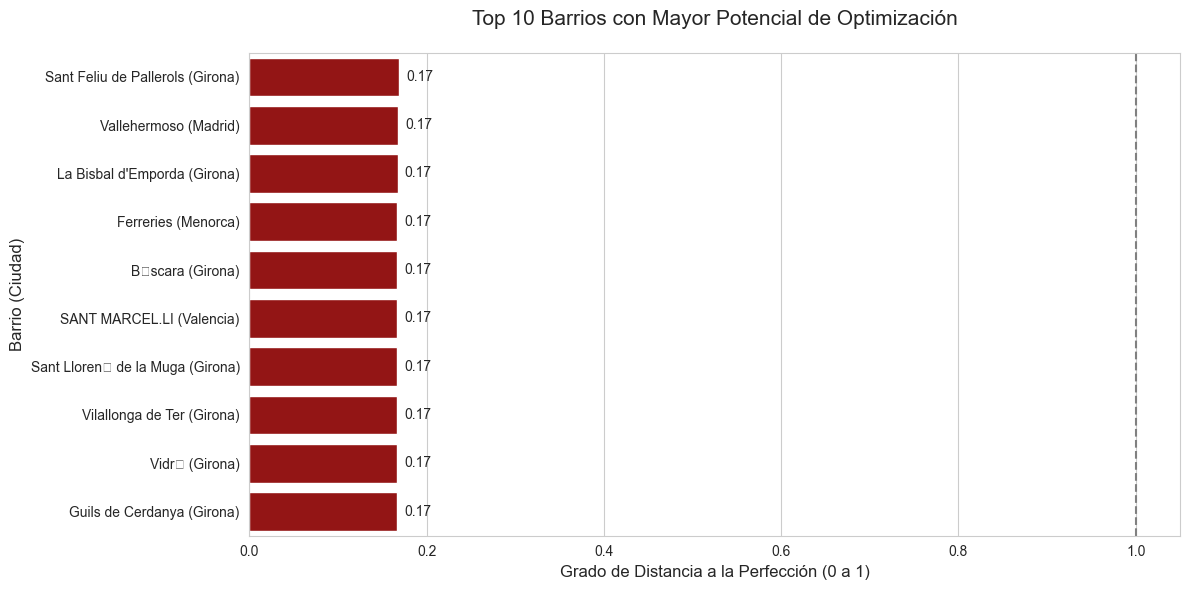

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionamos los 10 barrios con mayor Indice_Prioridad (los más "Rojos")
top_10_potencial = resultado_final.tail(10).copy()

# 2. Creamos una columna combinada de Barrio + Ciudad para el eje X
top_10_potencial['Etiqueta'] = top_10_potencial['neighbourhood_name'] + " (" + top_10_potencial['city'] + ")"

# 3. Configuramos el estilo visual
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 4. Dibujamos la barra del Índice de Prioridad
# Usamos el color corporativo NOK (#A80000) para resaltar la urgencia
ax = sns.barplot(
    x='Indice_Prioridad', 
    y='Etiqueta', 
    data=top_10_potencial, 
    color='#A80000' 
)

# 5. Añadimos la línea de "Perfección" (que sería el 0 de distancia, pero aquí el 1 es el máximo potencial)
plt.axvline(x=1, color='grey', linestyle='--', label='Máximo Potencial Teórico')

# 6. Títulos y etiquetas profesionales
plt.title('Top 10 Barrios con Mayor Potencial de Optimización', fontsize=15, pad=20)
plt.xlabel('Grado de Distancia a la Perfección (0 a 1)', fontsize=12)
plt.ylabel('Barrio (Ciudad)', fontsize=12)

# Añadimos los valores al final de cada barra para facilitar la lectura
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f', padding=5)

plt.tight_layout()
plt.show()

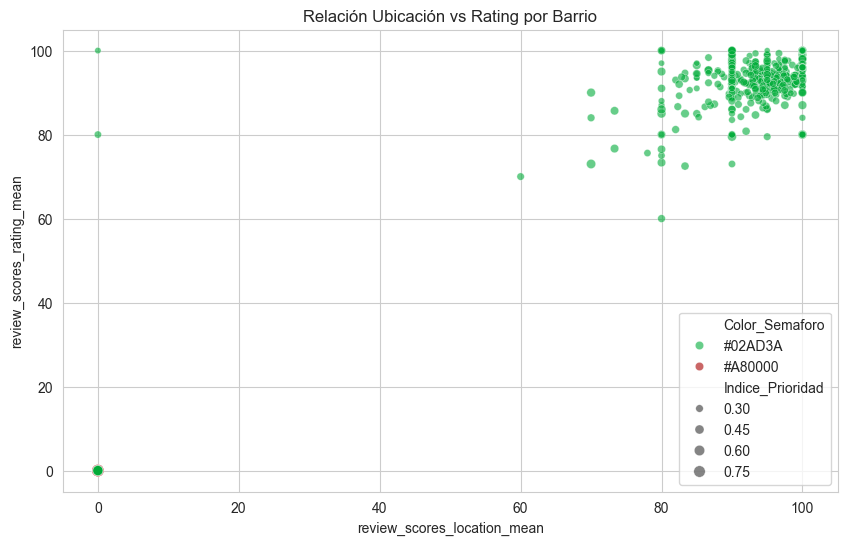

In [138]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_barrios, 
    x='review_scores_location_mean', 
    y='review_scores_rating_mean',
    size='Indice_Prioridad',
    hue='Color_Semaforo',
    palette={'#A80000': '#A80000', '#02AD3A': '#02AD3A'},
    alpha=0.6
)
plt.title('Relación Ubicación vs Rating por Barrio')
plt.show()